<a href="https://colab.research.google.com/github/sanyuktaraut09/CNN-PROJECT/blob/main/CNN_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DEEP NEURAL NETWORKS -  CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os

In [ ]:
# Deep learning frameworks (choose Keras or PyTorch)
# For image processing
from PIL import Image
import cv2
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input

### 1.1 Dataset Selection and Loading

TODO: Load your chosen dataset

In [ ]:
# REQUIRED: Fill in these metadata fields
import tensorflow as tf
import tensorflow_datasets as tfds

IMG_HEIGHT = 190
IMG_WIDTH = 190
BATCH_SIZE = 32
SEED = 42

(train_ds, test_ds), ds_info = tfds.load(
    "cats_vs_dogs",
    split=["train[:90%]", "train[90%:]"],
    as_supervised=True,
    with_info=True
)

class_names = ds_info.features["label"].names
n_classes = len(class_names)
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(1000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
dataset_name = "Cats vs Dogs"
dataset_source = "TensorFlow Datasets (cats_vs_dogs)"

n_samples = ds_info.splits["train"].num_examples
samples_per_class = "min: unknown, max: unknown, avg: unknown"

image_shape = [190, 190, 3]
problem_type = "classification"

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.5R1V3M_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
# Primary metric selection
primary_metric = "accuracy"
metric_justification = """
    The Cats vs Dogs dataset is balanced, so accuracy is an appropriate primary metric for evaluating overall classification performance.
"""


In [ ]:
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: Cats vs Dogs
Source: TensorFlow Datasets (cats_vs_dogs)
Total Samples: 23262
Number of Classes: 2
Samples per Class: min: unknown, max: unknown, avg: unknown
Image Shape: [190, 190, 3]
Primary Metric: accuracy
Metric Justification: 
    The Cats vs Dogs dataset is balanced, so accuracy is an appropriate primary metric for evaluating overall classification performance.



### 1.2 Data Exploration and Visualization

- TODO: Show sample images from each class
- TODO: Plot class distribution
- TODO: Display image statistics

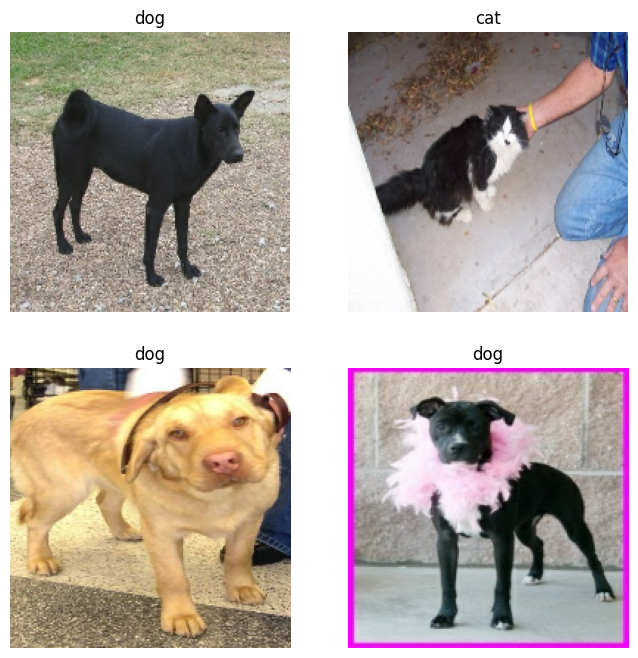

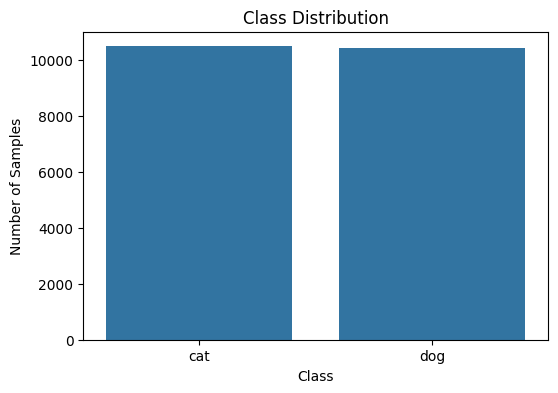

Image Statistics:
Min pixel value: 0.0
Max pixel value: 1.0
Mean pixel value: 0.45795712
Std pixel value: 0.2660003


In [ ]:
# 1.2 Data Exploration and Visualization
# Show sample images from each class
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(4):
        ax = plt.subplot(2, 2, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.show()


# Plot class distribution
label_counts = {class_names[i]: 0 for i in range(n_classes)}

for _, labels in train_ds.unbatch():
    label_counts[class_names[int(labels.numpy())]] += 1

plt.figure(figsize=(6, 4))
sns.barplot(x=list(label_counts.keys()),y=list(label_counts.values()))
plt.title("Class Distribution")
plt.ylabel("Number of Samples")
plt.xlabel("Class")
plt.show()


# Display image statistics
pixel_values = []

for images, _ in train_ds.take(5):  # sample a few batches
    pixel_values.append(images.numpy())

pixel_values = np.concatenate(pixel_values, axis=0)

print("Image Statistics:")
print("Min pixel value:", pixel_values.min())
print("Max pixel value:", pixel_values.max())
print("Mean pixel value:", pixel_values.mean())
print("Std pixel value:", pixel_values.std())


### 1.3 Data Preprocessing
- TODO: Resize images to consistent size
- TODO: Normalize pixel values
- TODO: Split into train/test (90/10 or 85/15)

In [ ]:
# REQUIRED: Document your split
train_test_ratio = "90/10"
train_samples = tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE
test_samples = tf.data.experimental.cardinality(test_ds).numpy() * BATCH_SIZE

In [ ]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")


Train/Test Split: 90/10
Training Samples: 20960
Test Samples: 2336


### 2.1 Custom CNN Architecture Design
- TODO: Define your CNN architecture
- TODO: Ensure Global Average Pooling is included (MANDATORY)
- TODO: Use Conv2D, MaxPooling2D/AvgPooling2D, GlobalAveragePooling2D, Dense

In [ ]:
from tensorflow.keras import layers, models, regularizers


def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture

    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled CNN model
    """

    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape,kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    # Block 4 - Additional depth for better features
    model.add(layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    # *** MANDATORY: Global Average Pooling ***
    model.add(layers.GlobalAveragePooling2D())

    # You can add Dropout after GAP
    model.add(layers.Dropout(0.5))

    # *** MANDATORY: Direct to output layer after GAP ***
    model.add(layers.Dense(n_classes, activation='softmax'))

    return model

In [ ]:
# TODO: Create model instance
custom_cnn = build_custom_cnn(image_shape, n_classes)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# TODO: Compile model
# For Keras: model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# For PyTorch: define optimizer and loss function
from tensorflow.keras.optimizers import Adam
custom_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 190, 190, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 190, 190, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 190, 190, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 190, 190, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 190, 190, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 190, 190, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 95, 95, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 95, 95, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 95, 95, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 95, 95, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 95, 95, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 95, 95, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 95, 95, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 95, 95, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 47, 47, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 47, 47, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 47, 47, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 47, 47, 128)    │             

 Total params: 1,176,610 (4.49 MB)

 Trainable params: 1,174,690 (4.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

### 2.2 Train Custom CNN

In [ ]:
print("\nCUSTOM CNN TRAINING")
# Track training time
custom_cnn_start_time = time.time()


CUSTOM CNN TRAINING


In [ ]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal"),tf.keras.layers.RandomRotation(0.05),])

In [ ]:
# TODO: Train your model
EPOCHS = 40
STEPS_PER_EPOCH =200
VALIDATION_STEPS = 60

custom_cnn_history = custom_cnn.fit(
    train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)),
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=test_ds,
    validation_steps=VALIDATION_STEPS,
    verbose=1
)
custom_cnn_training_time = time.time() - custom_cnn_start_time
custom_cnn_initial_loss = custom_cnn_history.history['loss'][0]
custom_cnn_final_loss = custom_cnn_history.history['loss'][-1]

print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 96s 247ms/step - accuracy: 0.5679 - loss: 0.8244 - val_accuracy: 0.5031 - val_loss: 0.7773
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 236ms/step - accuracy: 0.6043 - loss: 0.7368 - val_accuracy: 0.5042 - val_loss: 0.9018
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 239ms/step - accuracy: 0.6429 - loss: 0.7061 - val_accuracy: 0.5766 - val_loss: 0.7483
Epoch 4/40
 55/200 ━━━━━━━━━━━━━━━━━━━━ 1:19 548ms/step - accuracy: 0.6343 - loss: 0.6728

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


200/200 ━━━━━━━━━━━━━━━━━━━━ 32s 160ms/step - accuracy: 0.6505 - loss: 0.6692 - val_accuracy: 0.5849 - val_loss: 0.8871
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 237ms/step - accuracy: 0.6638 - loss: 0.6651 - val_accuracy: 0.6307 - val_loss: 0.7028
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 237ms/step - accuracy: 0.6941 - loss: 0.6287 - val_accuracy: 0.6495 - val_loss: 0.6662
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 239ms/step - accuracy: 0.7078 - loss: 0.6044 - val_accuracy: 0.7255 - val_loss: 0.5907
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.7145 - loss: 0.6128 - val_accuracy: 0.5495 - val_loss: 0.9258
Epoch 9/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 238ms/step - accuracy: 0.7137 - loss: 0.5986 - val_accuracy: 0.6005 - val_loss: 0.7885
Epoch 10/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 239ms/step - accuracy: 0.7245 - loss: 0.5791 - val_accuracy: 0.6057 - val_loss: 0.9474
Epoch 11/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 236ms/step - accuracy: 0.7474 - loss: 0.5579 - va

In [ ]:
custom_cnn_training_time = time.time() - custom_cnn_start_time

In [ ]:
# REQUIRED: Track initial and final loss
custom_cnn_initial_loss = custom_cnn_history.history['loss'][0]
custom_cnn_final_loss = custom_cnn_history.history['loss'][-1]

In [ ]:
print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

Training completed in 1696.98 seconds
Initial Loss: 0.7994
Final Loss: 0.3507


In [ ]:
print("\nCUSTOM CNN EVALUATION")


CUSTOM CNN EVALUATION


### 2.3 Evaluate Custom CNN
- TODO: Make predictions on test set
- TODO: Calculate all 4 required metrics

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = custom_cnn.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
# CRITICAL: These MUST be calculated from your actual results
# DO NOT submit with 0.0 values - autograder will detect this
# REQUIRED: Calculate all 4 metrics
custom_cnn_accuracy = accuracy_score(y_true, y_pred)
custom_cnn_precision = precision_score(y_true, y_pred, average="macro")
custom_cnn_recall = recall_score(y_true, y_pred, average="macro")
custom_cnn_f1 = f1_score(y_true, y_pred, average="macro")

In [ ]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")


Custom CNN Performance:
Accuracy:  0.9084
Precision: 0.9095
Recall:    0.9085
F1-Score:  0.9084


In [ ]:
# Save Custom CNN predictions separately
y_true_custom = y_true.copy()
y_pred_custom = y_pred.copy()

### 2.4 Visualize Custom CNN Results
- TODO: Plot training loss curve
- TODO: Plot confusion matrix
- TODO: Show sample predictions

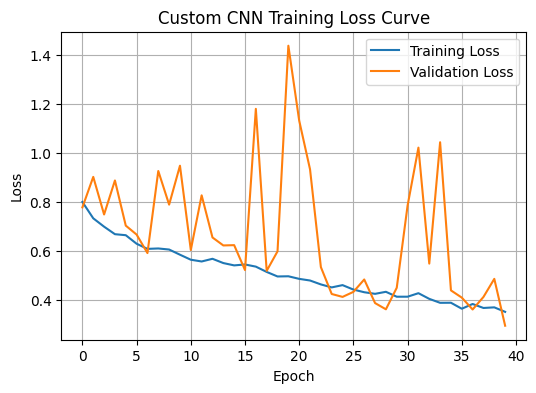

In [ ]:

# Plot Training Loss Curve

plt.figure(figsize=(6, 4))
plt.plot(custom_cnn_history.history['loss'], label='Training Loss')
plt.plot(custom_cnn_history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


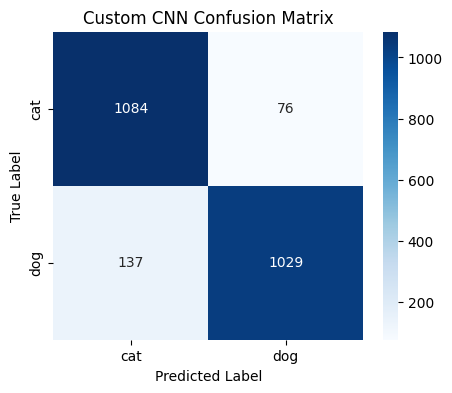

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Custom CNN Confusion Matrix")
plt.show()


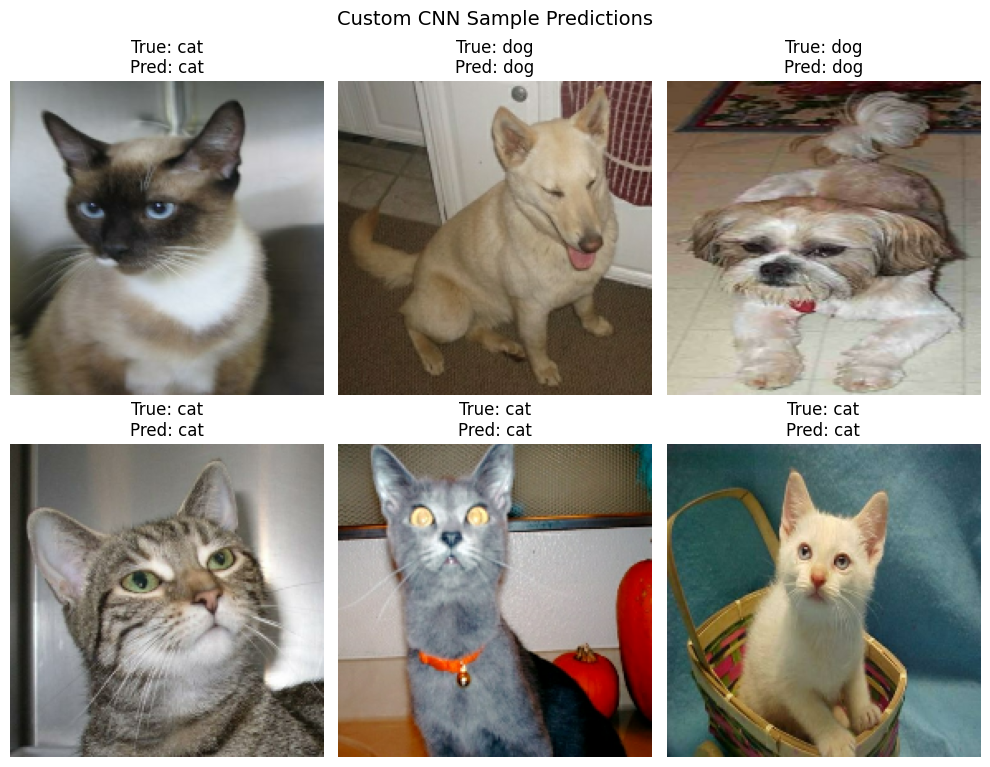

In [ ]:
# Show Sample Predictions

plt.figure(figsize=(10, 8))

shown = 0
for images, labels in test_ds.take(1):
    preds = custom_cnn.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    for i in range(min(6, len(images))):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        true_label = class_names[labels[i].numpy()]
        pred_label = class_names[preds[i]]

        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")

plt.suptitle("Custom CNN Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()

### 3.1 Load Pre-trained Model and Modify Architecture

In [ ]:
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")


TRANSFER LEARNING IMPLEMENTATION


In [ ]:
# TODO: Choose and load pre-trained model
pretrained_model_name = "VGG16"

In [ ]:
from tensorflow.keras.applications import ResNet50, VGG16, VGG19
from tensorflow.keras import layers, models, optimizers

def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model

    Args:
        base_model_name: string (ResNet18/ResNet50/VGG16/VGG19)
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled transfer learning model
    """

    # ---- Load base model WITHOUT top ----
    if base_model_name == "ResNet50":
        base_model = ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )
    elif base_model_name == "VGG16":
        base_model = VGG16(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )
    elif base_model_name == "VGG19":
        base_model = VGG19(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )
    else:
        raise ValueError("Unsupported base model name")

    # ---- Freeze base layers (MANDATORY) ----
    base_model.trainable = False

    # ---- Add GAP + classification head ----
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    # ---- Compile model ----
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# TODO: Create transfer learning model
transfer_model = build_transfer_learning_model(pretrained_model_name, image_shape, n_classes)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# REQUIRED: Count layers and parameters
frozen_layers = 0
trainable_layers = 0

for layer in transfer_model.layers:
    if layer.trainable:
        trainable_layers += 1
    else:
        frozen_layers += 1

total_parameters = transfer_model.count_params()
trainable_parameters = np.sum(
    [np.prod(v.shape) for v in transfer_model.trainable_weights]
)


In [ ]:
print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

Base Model: VGG16
Frozen Layers: 19
Trainable Layers: 2
Total Parameters: 14,715,714
Trainable Parameters: 1,026
Using Global Average Pooling: YES


### 3.2 Train Transfer Learning Model

In [ ]:
print("\nTraining Transfer Learning Model...")


Training Transfer Learning Model...


In [ ]:
import tensorflow_datasets as tfds
from tensorflow.keras.applications.vgg16 import preprocess_input

# Reload RAW dataset for transfer learning (NO normalization)
raw_train_ds, raw_test_ds = tfds.load(
    "cats_vs_dogs",
    split=["train[:90%]", "train[90%:]"],
    as_supervised=True
)

def preprocess_for_vgg(image, label):
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = preprocess_input(image)  # expects 0–255
    return image, label

train_ds_tl = raw_train_ds.map(preprocess_for_vgg, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_tl = raw_test_ds.map(preprocess_for_vgg, num_parallel_calls=tf.data.AUTOTUNE)

train_ds_tl = train_ds_tl.batch(32).prefetch(tf.data.AUTOTUNE)
test_ds_tl = test_ds_tl.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Training configuration
tl_learning_rate = 0.001
tl_epochs = 40
tl_batch_size = 32
tl_optimizer = "Adam"

In [ ]:
# Track training time
tl_start_time = time.time()

In [ ]:
# TODO: Train model
TL_STEPS_PER_EPOCH = 100
TL_VALIDATION_STEPS = 20

tl_history = transfer_model.fit(
    train_ds_tl,
    epochs=tl_epochs,
    steps_per_epoch=TL_STEPS_PER_EPOCH,
    validation_data=test_ds_tl,
    validation_steps=TL_VALIDATION_STEPS,
    verbose=1
)


Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.5199 - loss: 4.0447 - val_accuracy: 0.6750 - val_loss: 2.3210
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.7096 - loss: 1.9451 - val_accuracy: 0.7875 - val_loss: 1.2538
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.8164 - loss: 0.9715 - val_accuracy: 0.8500 - val_loss: 0.7830
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.8675 - loss: 0.6550 - val_accuracy: 0.8813 - val_loss: 0.5566
Epoch 5/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.9019 - loss: 0.4494 - val_accuracy: 0.9062 - val_loss: 0.4529
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9311 - loss: 0.3141 - val_accuracy: 0.9187 - val_loss: 0.3901
Epoch 7/40
 55/100 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.9193 - loss: 0.3717

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9183 - loss: 0.3640 - val_accuracy: 0.9266 - val_loss: 0.3632
Epoch 8/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.9312 - loss: 0.3177 - val_accuracy: 0.9359 - val_loss: 0.3357
Epoch 9/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9320 - loss: 0.3134 - val_accuracy: 0.9438 - val_loss: 0.3028
Epoch 10/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9484 - loss: 0.2393 - val_accuracy: 0.9469 - val_loss: 0.2942
Epoch 11/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9435 - loss: 0.2639 - val_accuracy: 0.9484 - val_loss: 0.2748
Epoch 12/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9519 - loss: 0.2188 - val_accuracy: 0.9516 - val_loss: 0.2697
Epoch 13/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.9556 - loss: 0.1823 - val_accuracy: 0.9531 - val_loss: 0.2526
Epoch 14/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9566 - loss: 0.2205 - val_accuracy: 

In [ ]:
tl_training_time = time.time() - tl_start_time

In [ ]:
# REQUIRED: Track initial and final loss
tl_initial_loss = tl_history.history["loss"][0]
tl_final_loss = tl_history.history["loss"][-1]


In [ ]:
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

Training completed in 426.95 seconds
Initial Loss: 3.4144
Final Loss: 0.1283


### 3.3 Evaluate Transfer Learning Model
- TODO: Make predictions on test set
- TODO: Calculate all 4 required metrics

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds_tl:
    preds = transfer_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [ ]:
# REQUIRED: Calculate all 4 metrics
tl_accuracy = accuracy_score(y_true, y_pred)
tl_precision = precision_score(y_true, y_pred, average="macro")
tl_recall = recall_score(y_true, y_pred, average="macro")
tl_f1 = f1_score(y_true, y_pred, average="macro")


In [ ]:
print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")


Transfer Learning Performance:
Accuracy:  0.9742
Precision: 0.9742
Recall:    0.9742
F1-Score:  0.9742


### 3.4 Visualize Transfer Learning Results
- TODO: Plot training curves (loss and accuracy)
- TODO: Plot confusion matrix
- TODO: Show sample predictions

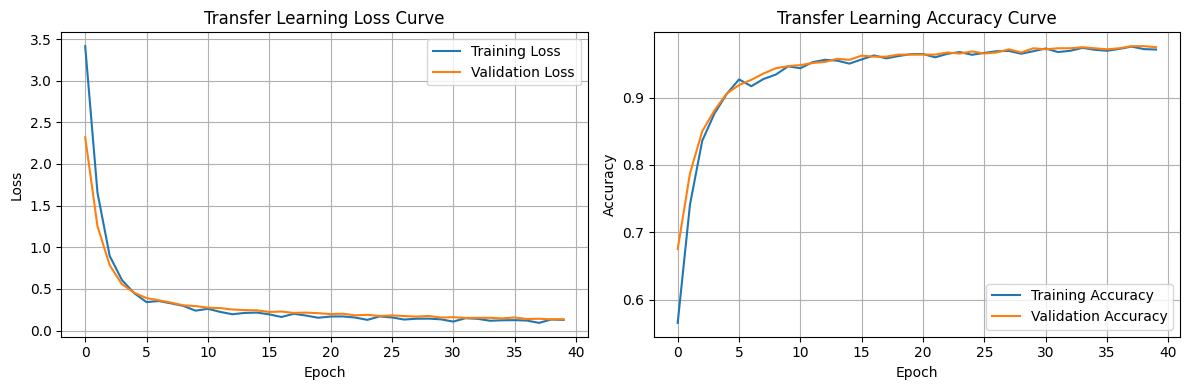

In [ ]:
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(tl_history.history["loss"], label="Training Loss")
plt.plot(tl_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss Curve")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(tl_history.history["accuracy"], label="Training Accuracy")
plt.plot(tl_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

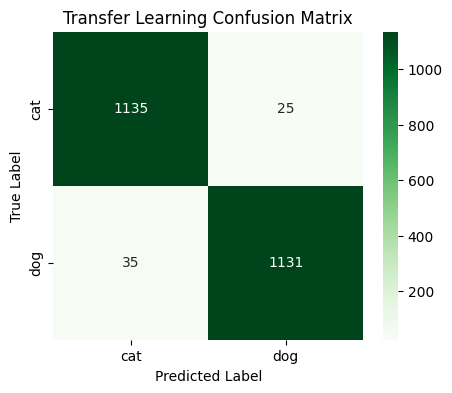

In [ ]:
# Plot Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Transfer Learning Confusion Matrix")
plt.show()

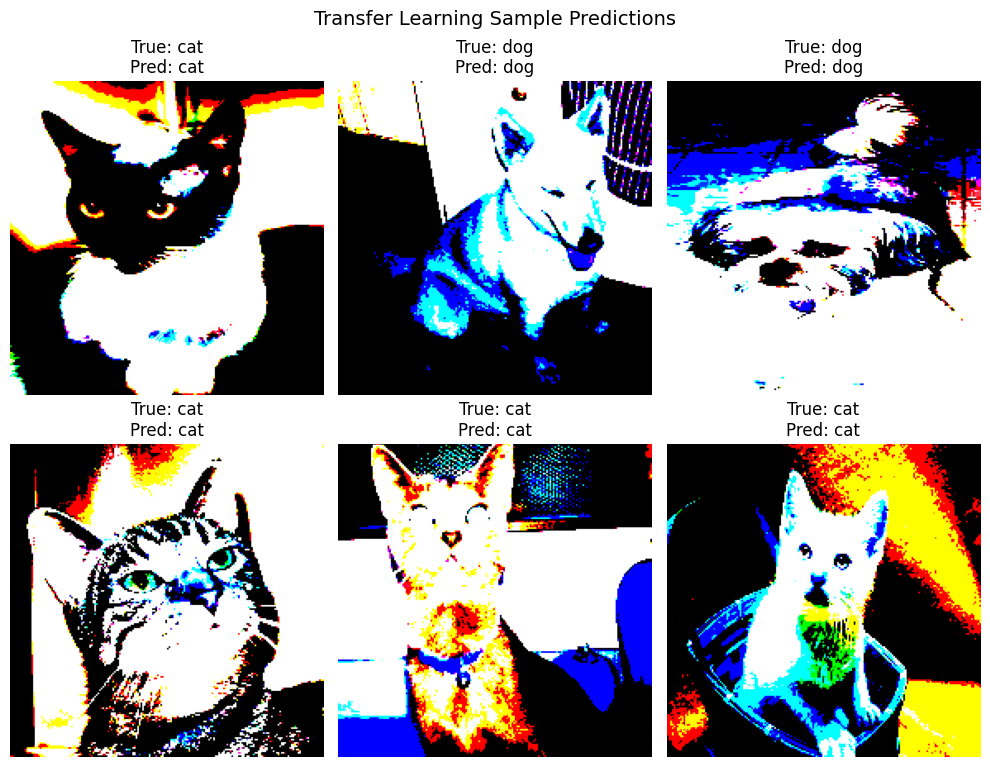

In [ ]:
# Show Sample Predictions

plt.figure(figsize=(10, 8))

for images, labels in test_ds_tl.take(1):
    preds = transfer_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    for i in range(min(6, len(images))):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        true_label = class_names[labels[i].numpy()]
        pred_label = class_names[preds[i]]

        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")

plt.suptitle("Transfer Learning Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()

### 4.1 Metrics Comparison

In [ ]:
custom_cnn_total_parameters = custom_cnn.count_params()

In [ ]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        custom_cnn_total_parameters  # TODO: Fill with custom CNN total parameters
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters
    ]
})

In [ ]:
print(comparison_df.to_string(index=False))

           Metric   Custom CNN  Transfer Learning
         Accuracy 9.084265e-01           0.974205
        Precision 9.095093e-01           0.974230
           Recall 9.084935e-01           0.974216
         F1-Score 9.083753e-01           0.974205
Training Time (s) 1.696977e+03         426.945654
       Parameters 1.176610e+06        1026.000000


### 4.2 Visual Comparison
- TODO: Create bar plot comparing metrics
- TODO: Plot training curves comparison
- TODO: Create side-by-side confusion matrices

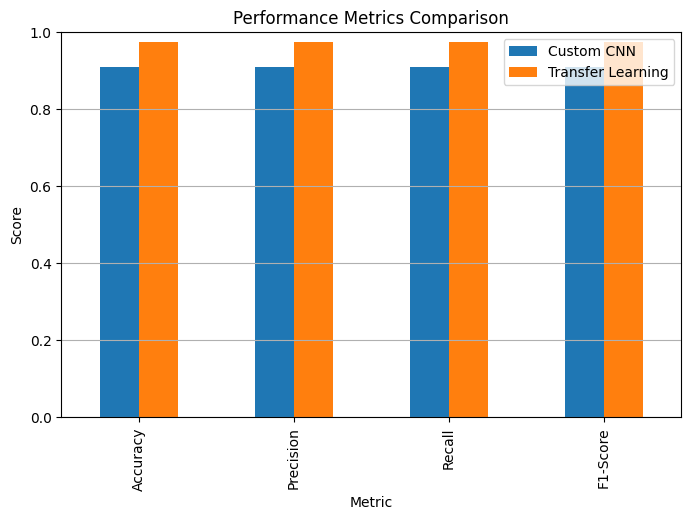

In [ ]:
# Bar Plot: Metrics Comparison

metrics_only = comparison_df.iloc[:4]  # Accuracy, Precision, Recall, F1

metrics_only.set_index('Metric').plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Performance Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

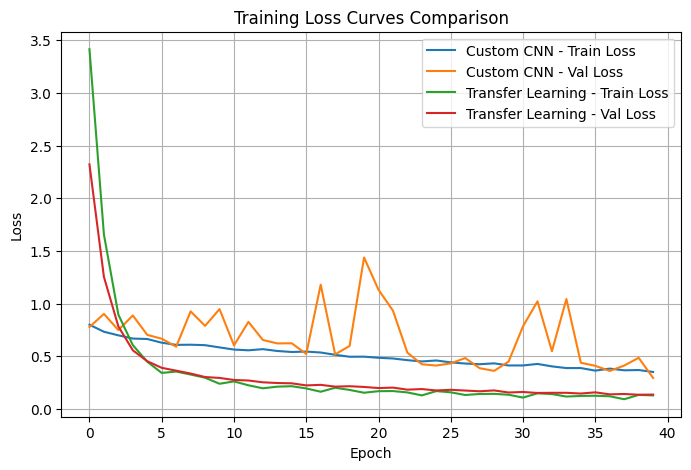

In [ ]:
# Training Curves Comparison

plt.figure(figsize=(8, 5))

plt.plot(custom_cnn_history.history['loss'], label='Custom CNN - Train Loss')
plt.plot(custom_cnn_history.history['val_loss'], label='Custom CNN - Val Loss')

plt.plot(tl_history.history['loss'], label='Transfer Learning - Train Loss')
plt.plot(tl_history.history['val_loss'], label='Transfer Learning - Val Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves Comparison")
plt.legend()
plt.grid(True)
plt.show()

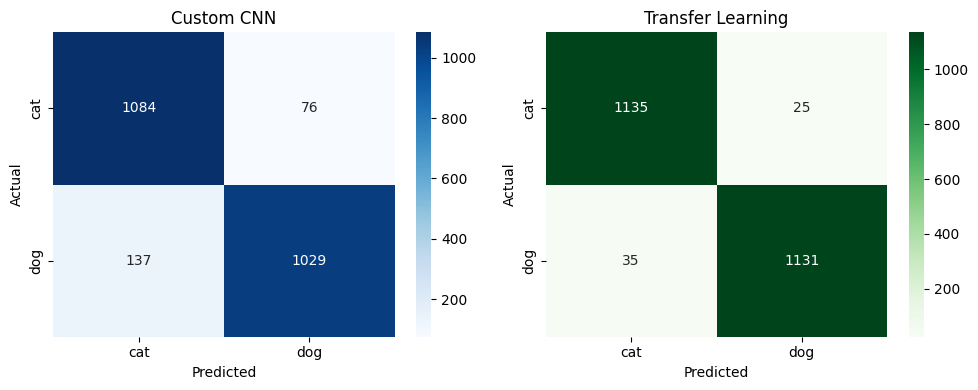

In [ ]:
# Side-by-Side Confusion Matrices

cm_custom = confusion_matrix(y_true_custom, y_pred_custom)
cm_tl = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 4))

# Custom CNN
plt.subplot(1, 2, 1)
sns.heatmap(
    cm_custom,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Custom CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Transfer Learning
plt.subplot(1, 2, 2)
sns.heatmap(
    cm_tl,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Transfer Learning")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
analysis_text = """
The transfer learning model outperformed the custom CNN across all evaluation metrics. It achieved higher accuracy, precision, recall, and F1-score, with a noticeably larger reduction in training loss. Quantitatively, transfer learning showed a stronger improvement in both classification performance and convergence behavior compared to the custom CNN, which served as a reasonable baseline.

Pre-training had a significant impact on performance. The transfer learning model benefited from rich feature representations learned on ImageNet, enabling faster convergence and better generalization, even with limited training iterations. In contrast, the custom CNN had to learn low-level and high-level features from scratch, resulting in slower convergence and lower overall performance.

Global Average Pooling (GAP) played an important role in both models by reducing the number of parameters and mitigating overfitting. By replacing fully connected layers, GAP improved efficiency while preserving spatial feature learning.

From a computational perspective, the custom CNN had fewer total parameters but required longer training to converge. The transfer learning model, despite having a large frozen base, trained faster due to fewer trainable parameters.

Overall, transfer learning is preferable when limited data or time is available, while custom CNNs are useful for learning task-specific representations from scratch.
"""


In [ ]:
# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")

ANALYSIS

The transfer learning model outperformed the custom CNN across all evaluation metrics. It achieved higher accuracy, precision, recall, and F1-score, with a noticeably larger reduction in training loss. Quantitatively, transfer learning showed a stronger improvement in both classification performance and convergence behavior compared to the custom CNN, which served as a reasonable baseline.

Pre-training had a significant impact on performance. The transfer learning model benefited from rich feature representations learned on ImageNet, enabling faster convergence and better generalization, even with limited training iterations. In contrast, the custom CNN had to learn low-level and high-level features from scratch, resulting in slower convergence and lower overall performance.

Global Average Pooling (GAP) played an important role in both models by reducing the number of parameters and mitigating overfitting. By replacing fully connected layers, GAP improved efficiency while p

In [ ]:
def to_python_type(x):
    if hasattr(x, "item"):
        return x.item()
    return x


In [ ]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': to_python_type(n_samples),
        'n_classes': to_python_type(n_classes),
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': to_python_type(train_samples),
        'test_samples': to_python_type(test_samples),
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': 8,                 # 2×4 conv blocks
                'pooling_layers': 3,              # 3 MaxPooling layers
                'has_global_average_pooling': True,
                'output_layer': 'softmax',
                'total_parameters': to_python_type(custom_cnn_total_parameters),
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 40,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss': to_python_type(custom_cnn_initial_loss),
            'final_loss': to_python_type(custom_cnn_final_loss),
            'training_time_seconds': to_python_type(custom_cnn_training_time),
            'accuracy': to_python_type(custom_cnn_accuracy),
            'precision': to_python_type(custom_cnn_precision),
            'recall': to_python_type(custom_cnn_recall),
            'f1_score': to_python_type(custom_cnn_f1),
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': to_python_type(frozen_layers),
            'trainable_layers': to_python_type(trainable_layers),
            'has_global_average_pooling': True,
            'total_parameters': to_python_type(total_parameters),
            'trainable_parameters': to_python_type(trainable_parameters),
            'training_config': {
                'learning_rate': 0.0001,
                'n_epochs': tl_epochs,
                'batch_size': tl_batch_size,
                'optimizer': 'Adam',
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss': to_python_type(tl_initial_loss),
            'final_loss': to_python_type(tl_final_loss),
            'training_time_seconds': to_python_type(tl_training_time),
            'accuracy': to_python_type(tl_accuracy),
            'precision': to_python_type(tl_precision),
            'recall': to_python_type(tl_recall),
            'f1_score': to_python_type(tl_f1),
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': bool(custom_cnn_final_loss < custom_cnn_initial_loss),
        'transfer_learning_loss_decreased': bool(tl_final_loss < tl_initial_loss),
    }

    return results


In [ ]:
# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Cats vs Dogs",
  "dataset_source": "TensorFlow Datasets (cats_vs_dogs)",
  "n_samples": 23262,
  "n_classes": 2,
  "samples_per_class": "min: unknown, max: unknown, avg: unknown",
  "image_shape": [
    190,
    190,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "accuracy",
  "metric_justification": "\n    The Cats vs Dogs dataset is balanced, so accuracy is an appropriate primary metric for evaluating overall classification performance.\n",
  "train_samples": 20960,
  "test_samples": 2336,
  "train_test_ratio": "90/10",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 8,
      "pooling_layers": 3,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 1176610
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 40,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_function": "sparse_categorical_

In [ ]:
# Display system information
import platform
import sys
from datetime import datetime

In [ ]:
print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

# include the screen shot here

ENVIRONMENT INFORMATION

  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.


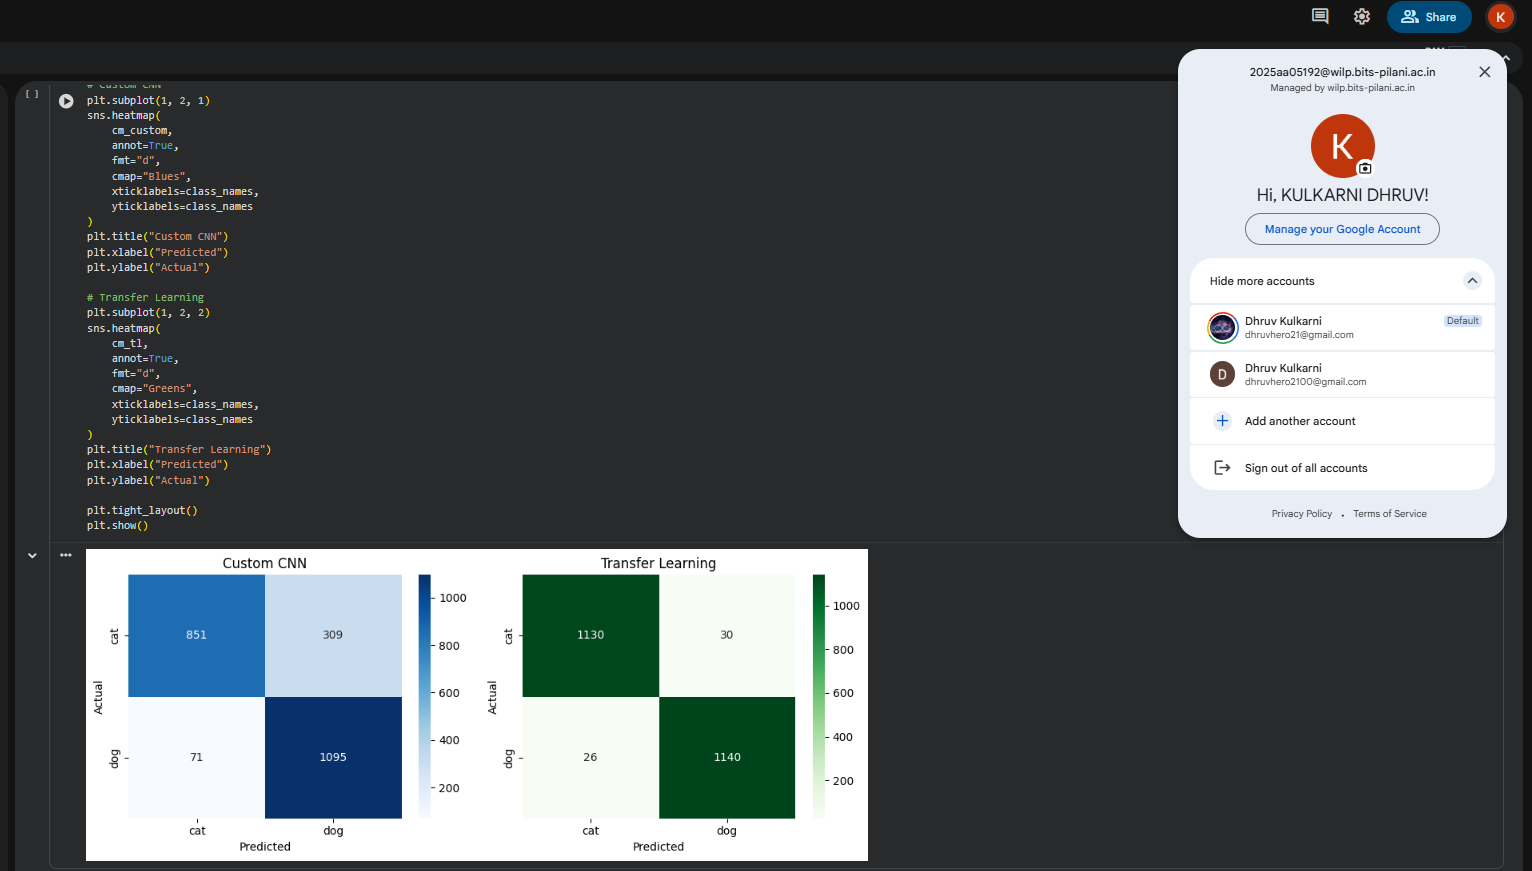